# Lab 8: Categorical Naive Bayes on Play Tennis Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import CategoricalNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load the dataset
df = pd.read_csv('data.csv')
df.head()

,No,Outlook,Temperature,Humidity,Wind,Play Tennis
0,1,Sunny,Hot,High,Weak,No
1,2,Sunny,Hot,High,Strong,No
2,3,Overcast,Hot,High,Weak,Yes
3,4,Rain,Mild,High,Weak,Yes
4,5,Rain,Cool,Normal,Weak,Yes


### 1 & 2. Separate input features and target variable

In [2]:
# Drop 'No' column as it is just an index
if 'No' in df.columns:
    df = df.drop('No', axis=1)

# Separate features and target variable
X = df.drop('Play Tennis', axis=1)
y = df['Play Tennis']

print("Features (X):\n", X.head())
print("\nTarget (y):\n", y.head())

Features (X):
     Outlook Temperature Humidity    Wind
0     Sunny         Hot     High    Weak
1     Sunny         Hot     High  Strong
2  Overcast         Hot     High    Weak
3      Rain        Mild     High    Weak
4      Rain        Cool   Normal    Weak

Target (y):
 0     No
1     No
2    Yes
3    Yes
4    Yes
Name: Play Tennis, dtype: str


### Data Visualizations: Exploring Features vs Target

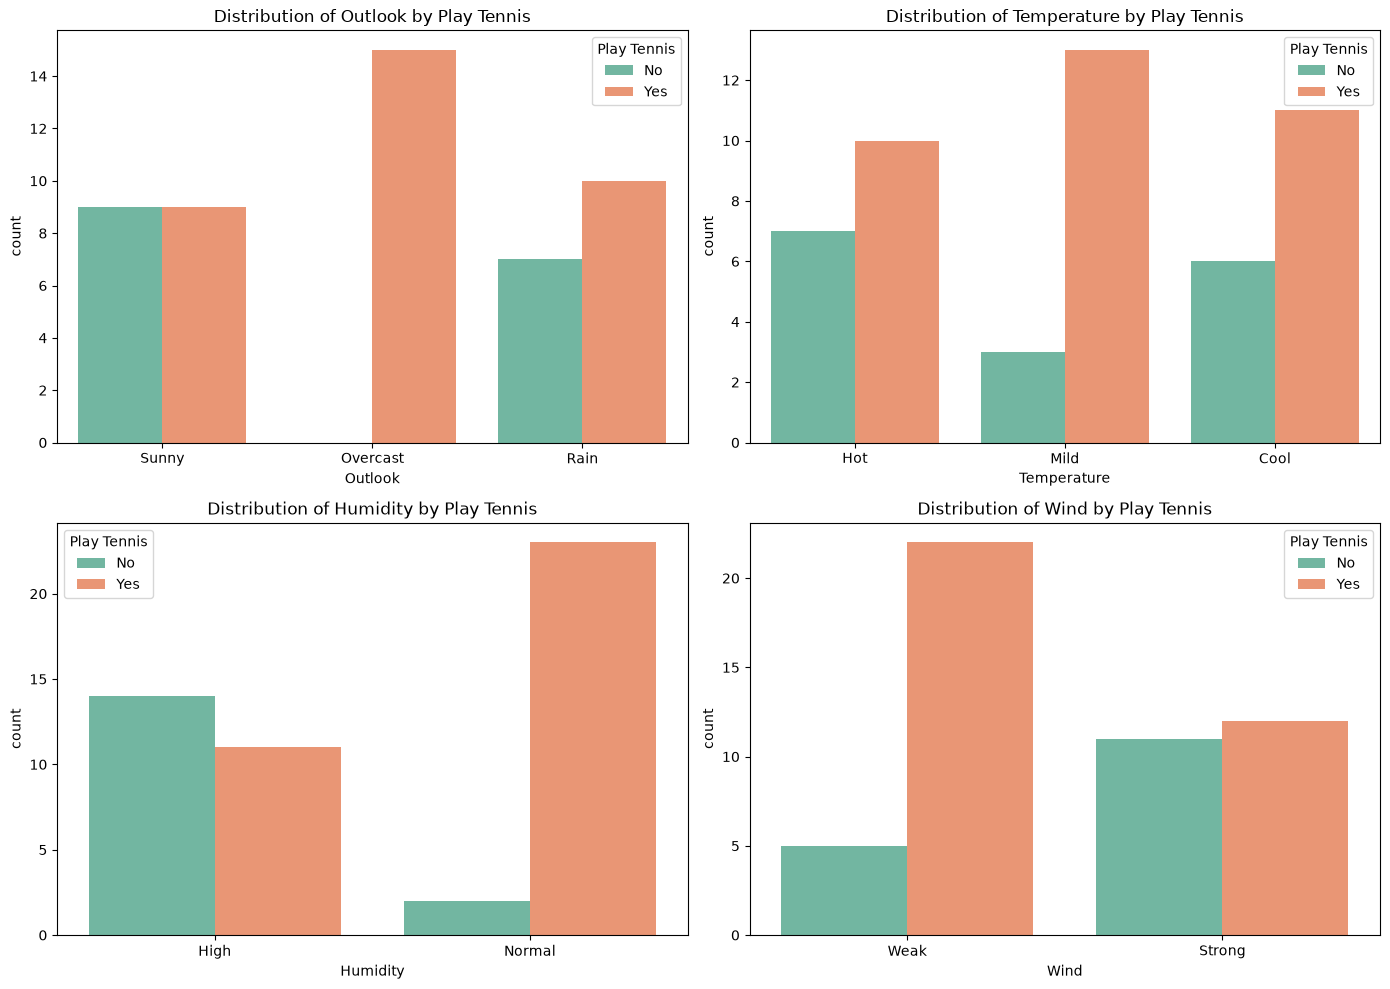

In [3]:
# Visualizing the dataset features vs the target variable
plt.figure(figsize=(14, 10))
for i, col in enumerate(X.columns):
    plt.subplot(2, 2, i+1)
    sns.countplot(x=col, hue=y, data=df, palette='Set2')
    plt.title(f'Distribution of {col} by Play Tennis')
plt.tight_layout()
plt.show()

### 3. Convert categorical values into numerical values

In [4]:
# Convert categorical values to numerical values using LabelEncoder
label_encoders = {}
for column in X.columns:
    le = LabelEncoder()
    X[column] = le.fit_transform(X[column])
    label_encoders[column] = le

# Encode the target variable
le_y = LabelEncoder()
y = le_y.fit_transform(y)

print("Encoded Features (X):\n", X.head())
print("\nEncoded Target (y):\n", y[:5])

Encoded Features (X):
    Outlook  Temperature  Humidity  Wind
0        2            1         0     1
1        2            1         0     0
2        0            1         0     1
3        1            2         0     1
4        1            0         1     1

Encoded Target (y):
 [0 0 1 1 1]


### 4. Divide dataset into training and testing sets

In [5]:
# Divide the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

Training set size: 35
Testing set size: 15


### 5. Train a Categorical Naive Bayes model

In [6]:
# Train a Categorical Naive Bayes model
cnb = CategoricalNB()
cnb.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"min_categories min_categories: int or array-like of shape (n_features,), default=NoneMinimum number of categories per feature.- integer: Sets the minimum number of categories per feature to `n_categories` for each features.- array-like: shape (n_features,) where `n_categories[i]` holds the minimum number of categories for the ith column of the input.- None (default): Determines the number of categories automatically from the training data... versionadded:: 0.24",None
Name,Type,Value
"category_count_ category_count_: list of arrays of shape (n_features,)Holds arrays of shape (n_classes, n_categories of respective feature)for each feature. Each array provides the number of samplesencountered for each class and category of the specific feature.",list,"[array([[ 0., ...., 6., 4.]]), array([[ 6., ...., 7., 10.]]), array([[13., ... [ 7., 14.]]), array([[ 9., ... [ 8., 13.]])]"
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[14.,21.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.92,-0.51]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_log_prob_ feature_log_prob_: list of arrays of shape (n_features,)Holds arrays of shape (n_classes, n_categories of respective feature)for each feature. Each array provides the empirical log probabilityof categories given the respective feature and class, ``P(x_i|y)``.",list,"[array([[-2.83...-1.56861592]]), array([[-0.88...-0.78015856]]), array([[-0.13...-0.42744401]]), array([[-0.47...-0.49643689]])]"


### 6. Predict the class labels for the test dataset

In [7]:
# Predict class labels for the test dataset
y_pred_cnb = cnb.predict(X_test)
print("Predicted values:", y_pred_cnb)
print("Actual values:   ", y_test)

Predicted values: [0 1 0 1 1 1 0 1 1 1 1 1 1 1 1]
Actual values:    [0 1 1 1 1 1 1 0 1 1 1 1 1 1 1]


### 7. Calculate and display accuracy, confusion matrix and classification report

Categorical Naive Bayes Performance:

Accuracy: 0.8000

Confusion Matrix:
 [[ 1  1]
 [ 2 11]]

Classification Report:
               precision    recall  f1-score   support

          No       0.33      0.50      0.40         2
         Yes       0.92      0.85      0.88        13

    accuracy                           0.80        15
   macro avg       0.62      0.67      0.64        15
weighted avg       0.84      0.80      0.82        15



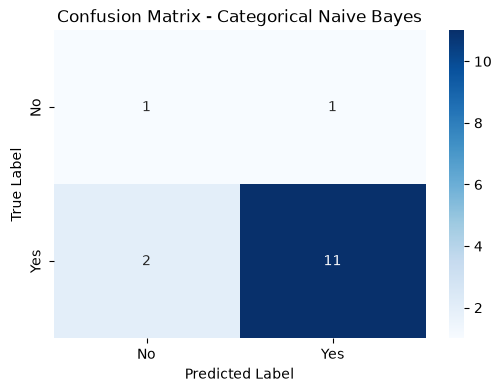

In [8]:
# Calculate and display accuracy, confusion matrix, and classification report
print("Categorical Naive Bayes Performance:\n")
acc_cnb = accuracy_score(y_test, y_pred_cnb)
print(f"Accuracy: {acc_cnb:.4f}")

cm = confusion_matrix(y_test, y_pred_cnb)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred_cnb, target_names=le_y.classes_))

# Visualize the Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le_y.classes_, yticklabels=le_y.classes_)
plt.title('Confusion Matrix - Categorical Naive Bayes')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### 8. Predict for given weather condition

Condition: Outlook: Sunny, Temperature: Cool, Humidity: High, Wind: Strong
Predicted Class: No
Class Probabilities: [0.93729886 0.06270114]


/tmp/ipykernel_1968844/2096282948.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=le_y.classes_, y=pred_prob[0], palette='pastel')


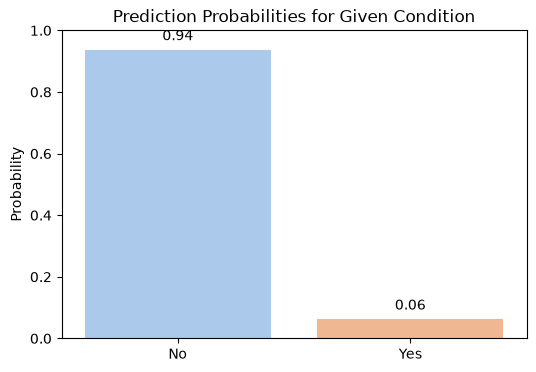

In [9]:
# Predict for: Outlook=Sunny, Temperature=Cool, Humidity=High, Wind=Strong
new_data = pd.DataFrame({
    'Outlook': ['Sunny'],
    'Temperature': ['Cool'],
    'Humidity': ['High'],
    'Wind': ['Strong']
})

# Encode the new data
for column in new_data.columns:
    new_data[column] = label_encoders[column].transform(new_data[column])

# Predict class and probabilities
pred = cnb.predict(new_data)
pred_prob = cnb.predict_proba(new_data)

predicted_class = le_y.inverse_transform(pred)[0]

print("Condition: Outlook: Sunny, Temperature: Cool, Humidity: High, Wind: Strong")
print(f"Predicted Class: {predicted_class}")
print(f"Class Probabilities: {pred_prob[0]}")

# Visualize the Prediction Probabilities
plt.figure(figsize=(6, 4))
sns.barplot(x=le_y.classes_, y=pred_prob[0], palette='pastel')
plt.title('Prediction Probabilities for Given Condition')
plt.ylabel('Probability')
plt.ylim(0, 1.0)
for i, prob in enumerate(pred_prob[0]):
    plt.text(i, prob + 0.02, f'{prob:.2f}', ha='center', va='bottom')
plt.show()

### 9. Compare the performance with Decision Tree and Logistic Regression

Model Comparison - Accuracy
------------------------------
Categorical Naive Bayes : 0.8000
Decision Tree           : 0.6000
Logistic Regression     : 0.5333


/tmp/ipykernel_1968844/2201860308.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='viridis')


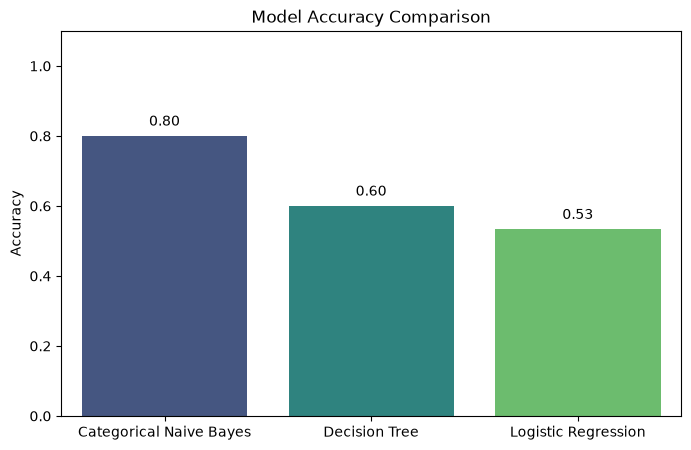

In [10]:
# Compare performance with Decision Tree and Logistic Regression
# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)

# Logistic Regression
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)

print("Model Comparison - Accuracy")
print("-" * 30)
print(f"Categorical Naive Bayes : {acc_cnb:.4f}")
print(f"Decision Tree           : {acc_dt:.4f}")
print(f"Logistic Regression     : {acc_lr:.4f}")

# Visualize Model Comparison
models = ['Categorical Naive Bayes', 'Decision Tree', 'Logistic Regression']
accuracies = [acc_cnb, acc_dt, acc_lr]

plt.figure(figsize=(8, 5))
sns.barplot(x=models, y=accuracies, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1.1)
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.02, f'{v:.2f}', ha='center', va='bottom')
plt.show()